# Model Interpretation and Confidence Analysis

This notebook provides tools for interpreting model predictions, analyzing confidence distributions, and evaluating pseudo‑label quality in SSL experiments.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (12, 8)

## Load Model and Test Predictions

Load a trained model and compute predictions on the test set.

In [2]:
import sys
from pathlib import Path
sys.path.append('..')
from src.data.dataset import CBISDDSMDataset
from src.models.efficientnet import EfficientNetClassifier
from src.data.transforms import get_transforms, IMAGENET_MEAN, IMAGENET_STD
from src.training import get_device
import yaml

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / 'configs').exists() and (candidate / 'src').exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not locate project root from the current notebook kernel.')

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'notebooks'
DATA_DIR = PROJECT_ROOT / 'data'
DEFAULT_EXPERIMENT = PROJECT_ROOT / 'results_v2' / 'supervised_500'
config_path = DEFAULT_EXPERIMENT / 'config.yaml'
checkpoint_path = DEFAULT_EXPERIMENT / 'best_model.pth'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

image_size = config['dataset']['image_size']
test_transform = get_transforms('test', image_size=image_size)

def denormalize_image(tensor):
    mean = torch.tensor(IMAGENET_MEAN, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    image = tensor.detach().cpu() * std.cpu() + mean.cpu()
    return image.clamp(0, 1)

test_dataset = CBISDDSMDataset(
    data_dir=str(PROJECT_ROOT / 'data'),
    abnormality_type=config['dataset']['abnormality_type'],
    split='test',
    transform=test_transform,
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

model = EfficientNetClassifier(
    num_classes=config['model']['num_classes'],
    pretrained=False,
    dropout_rate=config['model'].get('dropout_rate', 0.2),
    freeze_backbone=config['model'].get('freeze_backbone', False),
)
checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

device = get_device()
model.to(device)

all_preds = []
all_probs = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = F.softmax(logits, dim=1)
        _, preds = torch.max(logits, 1)
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

preds = np.concatenate(all_preds)
probs = np.vstack(all_probs)
labels = np.concatenate(all_labels)

print(f'Predictions shape: {preds.shape}')
print(f'Probabilities shape: {probs.shape}')
print(f'Labels shape: {labels.shape}')


Predictions shape: (361,)
Probabilities shape: (361, 2)
Labels shape: (361,)


## Confidence Distributions

Plot histograms of predicted confidence (probability of the predicted class) for correct vs incorrect predictions.

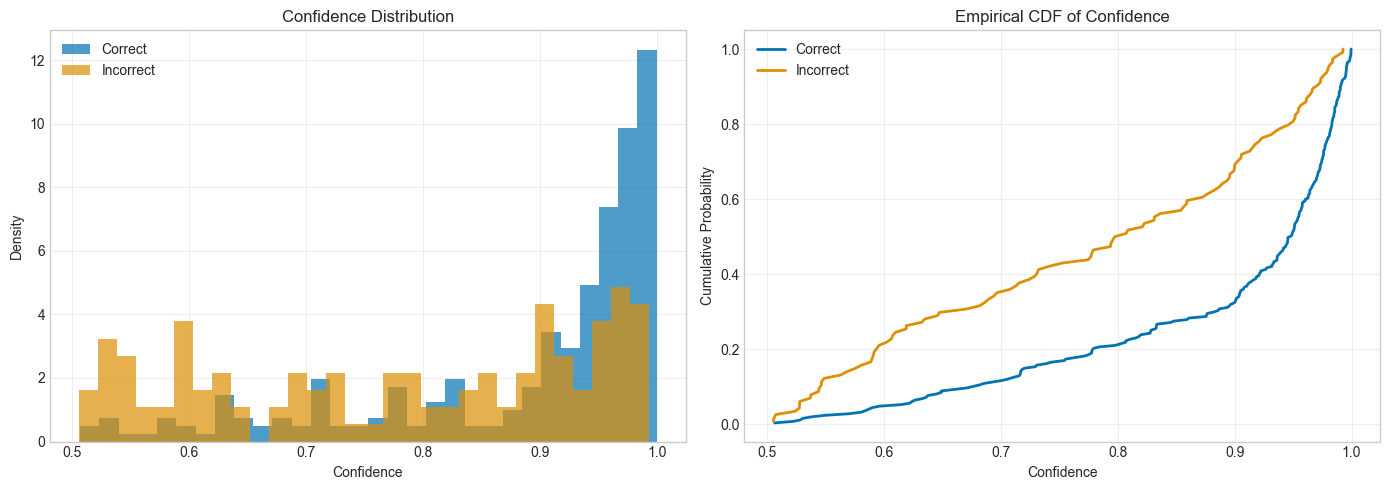

In [3]:
correct = (preds == labels)
confidences = probs[np.arange(len(preds)), preds]  # confidence of predicted class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(confidences[correct], bins=30, alpha=0.7, label='Correct', density=True)
axes[0].hist(confidences[~correct], bins=30, alpha=0.7, label='Incorrect', density=True)
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Density')
axes[0].set_title('Confidence Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ECDF
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_corr, y_corr = ecdf(confidences[correct])
x_inc, y_inc = ecdf(confidences[~correct])
axes[1].plot(x_corr, y_corr, label='Correct', linewidth=2)
axes[1].plot(x_inc, y_inc, label='Incorrect', linewidth=2)
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Empirical CDF of Confidence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Calibration Plot

Assess how well predicted probabilities match true accuracy (calibration).

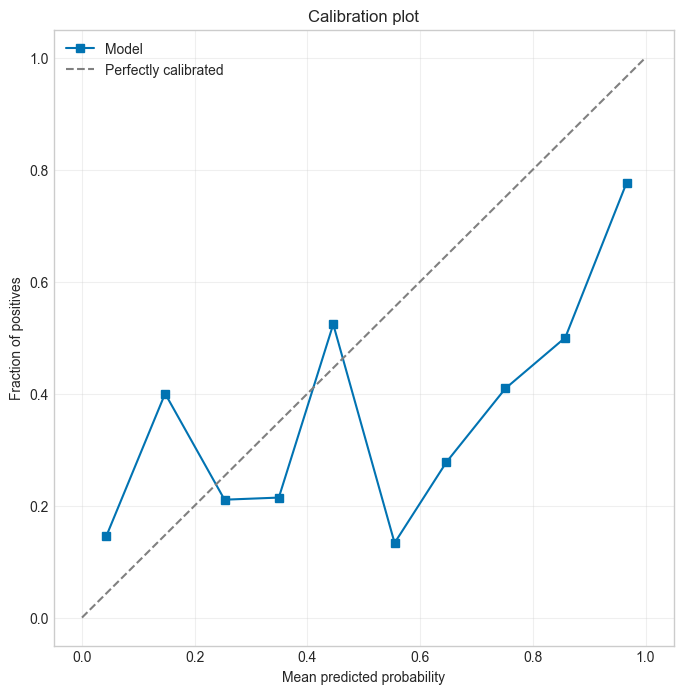

In [4]:
from sklearn.calibration import calibration_curve

# Binary classification: probability of class 1 (malignant)
prob_pos = probs[:, 1]
true_labels = labels

fraction_of_positives, mean_predicted_value = calibration_curve(
    true_labels, prob_pos, n_bins=10, strategy='uniform'
)

plt.figure(figsize=(8, 8))
plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Pseudo‑Label Quality (SSL)

For FixMatch experiments, analyze the accuracy of pseudo‑labels on unlabeled data.

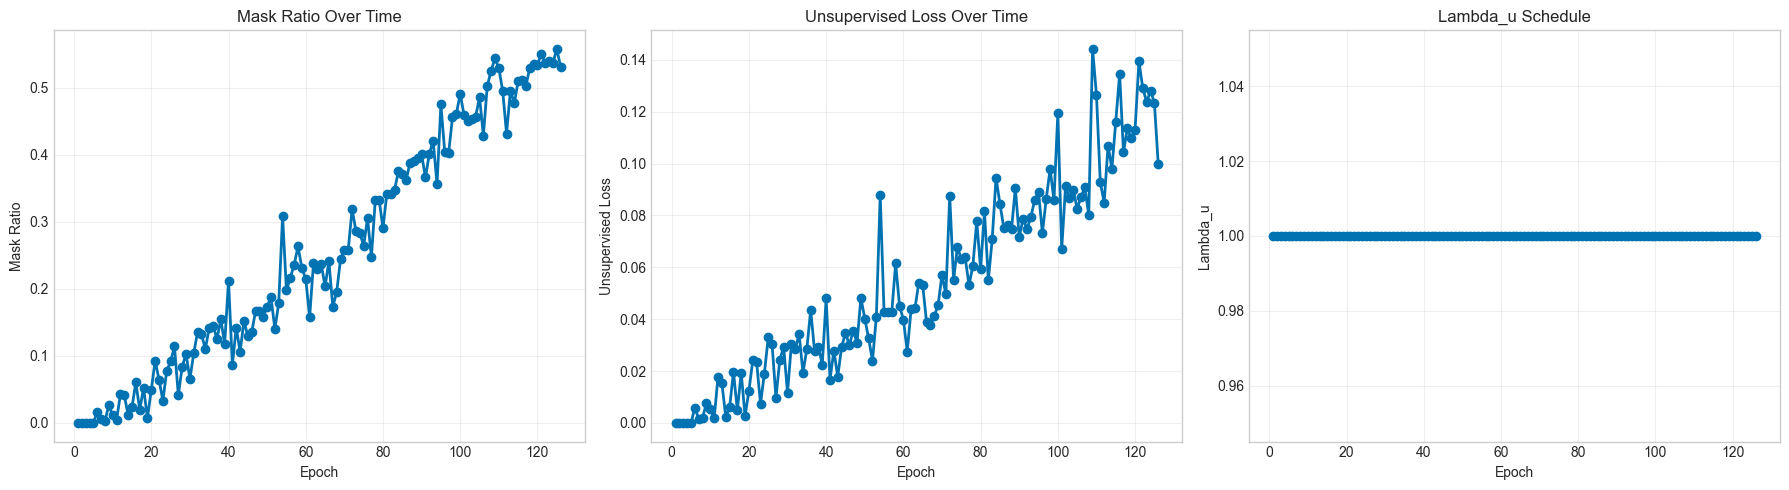

In [5]:
# SSL training dynamics from current FixMatch logs
training_history = PROJECT_ROOT / 'results_v2' / 'fixmatch_500' / 'training_history.csv'
if training_history.exists():
    pl_df = pd.read_csv(training_history)
    pl_df['epoch'] = np.arange(1, len(pl_df) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if 'mask_ratio' in pl_df.columns:
        axes[0].plot(pl_df['epoch'], pl_df['mask_ratio'], marker='o', linewidth=2)
        axes[0].set_title('Mask Ratio Over Time')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Mask Ratio')
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, 'mask_ratio not available', ha='center', va='center')

    if 'unsup_loss' in pl_df.columns:
        axes[1].plot(pl_df['epoch'], pl_df['unsup_loss'], marker='o', linewidth=2)
        axes[1].set_title('Unsupervised Loss Over Time')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Unsupervised Loss')
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, 'unsup_loss not available', ha='center', va='center')

    if 'lambda_u' in pl_df.columns:
        axes[2].plot(pl_df['epoch'], pl_df['lambda_u'], marker='o', linewidth=2)
        axes[2].set_title('Lambda_u Schedule')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Lambda_u')
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(0.5, 0.5, 'lambda_u not available', ha='center', va='center')

    plt.tight_layout()
    plt.show()
else:
    print('No FixMatch training history found. Run SSL experiments first.')


## Grad‑CAM Visualization

Generate Grad‑CAM heatmaps to see which image regions influence the model's decision.

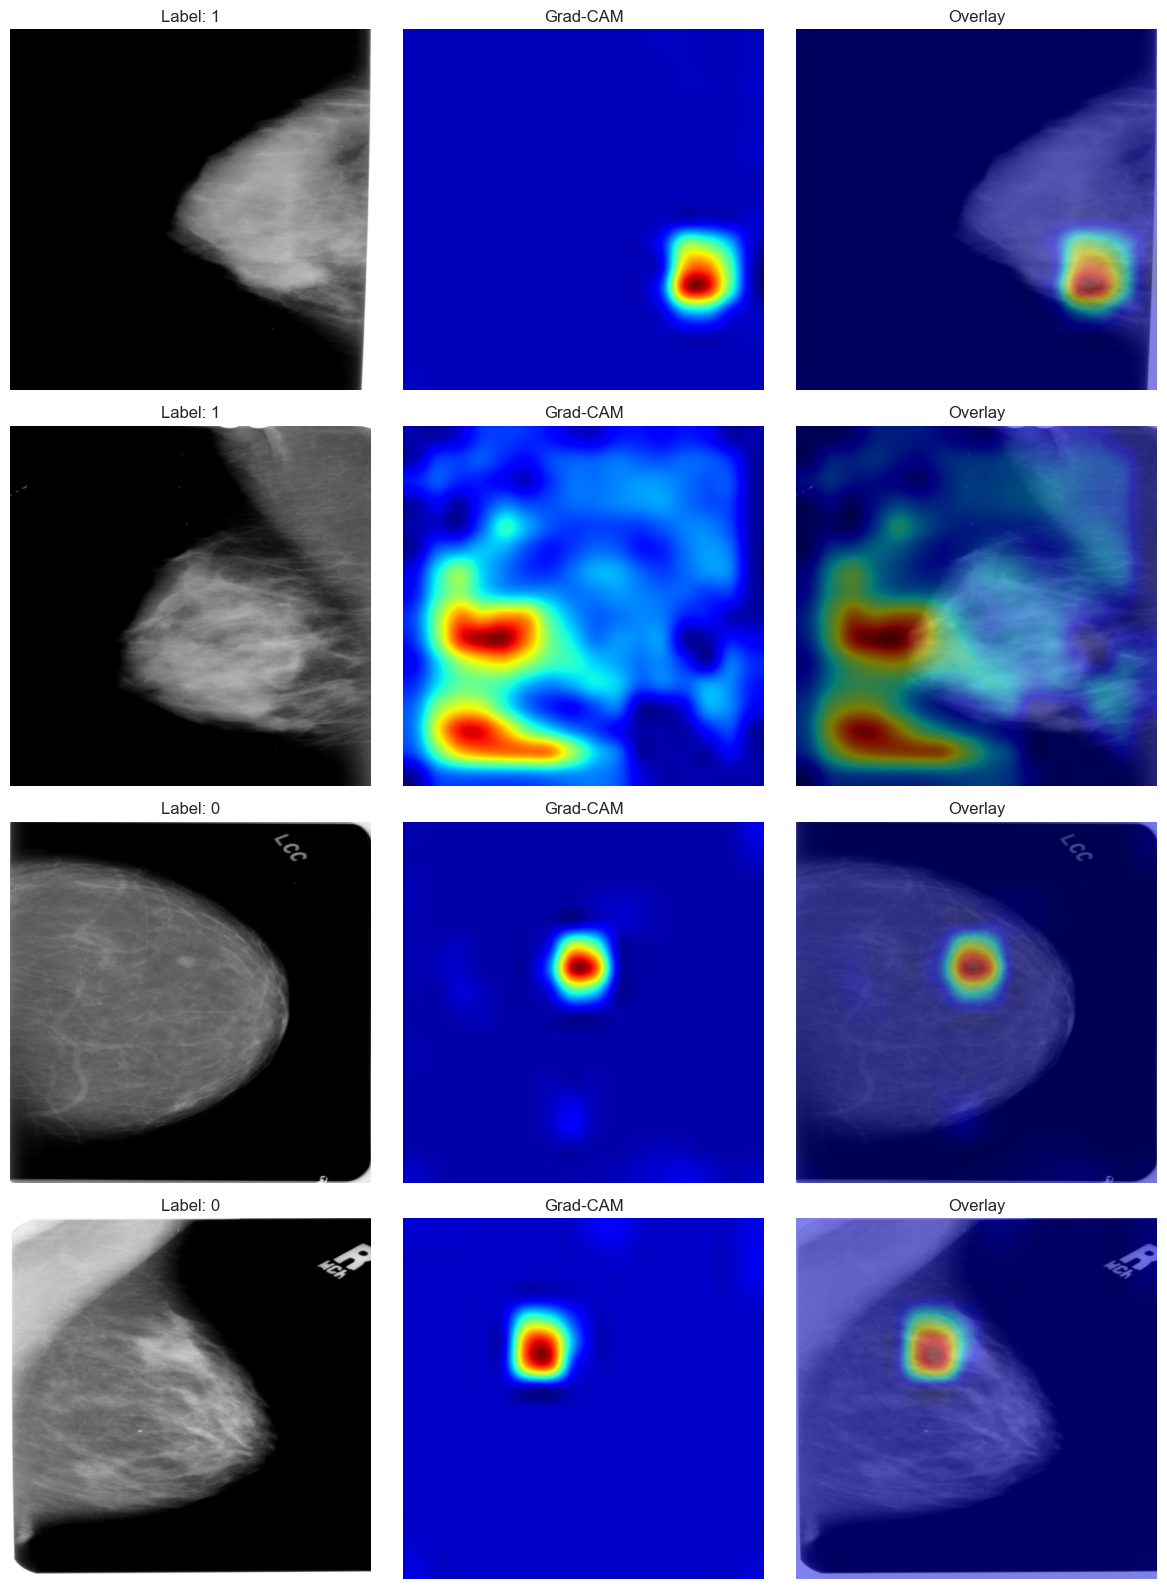

In [3]:
# Grad-CAM implementation for EfficientNet
from PIL import Image as PILImage

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output
            self.gradients = None
            output.register_hook(self._save_gradients)

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))

    def _save_gradients(self, grad):
        self.gradients = grad

    def __call__(self, input_tensor, class_idx=None):
        self.gradients = None
        self.activations = None
        input_tensor = input_tensor.requires_grad_(True)

        self.model.zero_grad()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx].sum()
        score.backward()

        if self.gradients is None or self.activations is None:
            raise RuntimeError(
                'Grad-CAM hooks did not capture activations/gradients. '
                'Try a different target layer or verify the model forward path.'
            )

        grads = self.gradients.detach().cpu().numpy()[0]
        acts = self.activations.detach().cpu().numpy()[0]
        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)
        for i, weight in enumerate(weights):
            cam += weight * acts[i]
        cam = np.maximum(cam, 0)
        cam = np.array(PILImage.fromarray(cam).resize((input_tensor.shape[3], input_tensor.shape[2])))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def cleanup(self):
        for handle in self.hook_handles:
            handle.remove()

if 'test_dataset' in locals():
    indices = [0, 10, 20, 30]
    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)

    target_layer = model.backbone.features[-1]
    gradcam = GradCAM(model, target_layer)

    for idx, sample_idx in enumerate(indices):
        img, label = test_dataset[sample_idx]
        input_tensor = img.unsqueeze(0).to(device)
        cam = gradcam(input_tensor)

        img_np = denormalize_image(img).permute(1, 2, 0).numpy()
        axes[idx, 0].imshow(img_np)
        axes[idx, 0].set_title(f'Label: {label}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(cam, cmap='jet')
        axes[idx, 1].set_title('Grad-CAM')
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(img_np)
        axes[idx, 2].imshow(cam, cmap='jet', alpha=0.5)
        axes[idx, 2].set_title('Overlay')
        axes[idx, 2].axis('off')

    gradcam.cleanup()
    plt.tight_layout()
    plt.show()
else:
    print('Test dataset not loaded.')


## Confusion Matrix

Compute and visualize the confusion matrix.

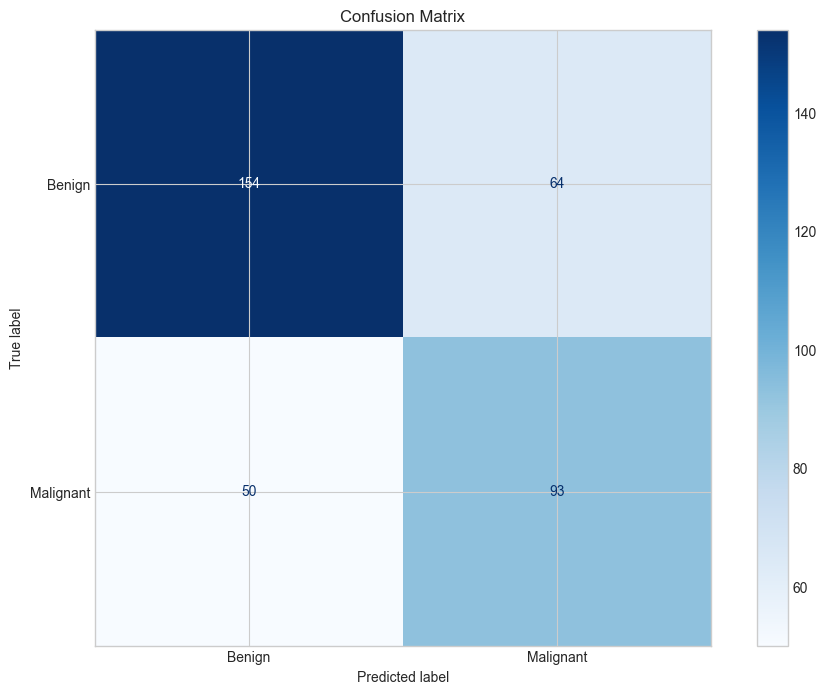

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## Summary

This notebook provides multiple tools for model interpretation:
- Confidence distributions and calibration
- Pseudo‑label quality analysis (SSL)
- Grad‑CAM visualization for spatial attention
- Confusion matrix for error analysis